# [실습] 80% 구간 포함률 — 주를 나눠 구하고 비교하기

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## 80% 구간을 인력 계획에 믿고 쓸까

<div style="background:#FFFFFF;color:#000000;padding:40px;border-radius:12px;border:1px solid #E6E6E6;border-left:4px solid #051C2C">
<div style="font-size:0.9em;color:#656565">딥러닝 시계열 · 넷째 날</div>
<h1 style="color:#000000;margin:10px 0">80% 구간 포함률 — 주를 나눠 구하고 비교하기</h1>
<div style="font-size:1.05em;color:#656565">Chronos-2 두 모델의 분위수 열로 80% 구간을 꺼내, 그 포함률과 평균 구간 길이를 공휴일 없는 두 주와 공휴일 있는 세 주로 나눠 구합니다</div>
</div>

**오늘의 질문** 공휴일 열을 입력한 Chronos-2 가 낸 80% 구간을 다음 주 역별 인력 계획에 그대로 써도 될까요?

두 모델은 Chronos-2 제로샷과 공변량을 배울 때 평가표에 MASE 를 적은 Chronos-2 입니다. **제로샷**(평가표의 「Chronos-2 제로샷」)은 가중치를 고치지 않고 사전학습한 그대로 예측한 Chronos-2 입니다. **Chronos-2 + 공휴일**은 공휴일 열을 과거 표 `df` 와 미래 입력 `future_df` 에 함께 포함한 Chronos-2 입니다.

둘 다 원점 전날까지 512일(컨텍스트)을 입력하면 역·날마다 분위수 아홉 열 `"0.1"`～`"0.9"` 를 냅니다. 지금까지는 그 가운데 `"0.5"` 열만 점 예측으로 채점했습니다.

80% 구간은 분위수 0.1 열과 0.9 열 사이입니다. 대상은 서울 지하철 100개 역(2024년까지 하루 평균 승차가 가장 많은 역 100곳)입니다.

**예측 원점(forecast origin)** 하나마다 100개 역 × 7일 = 700점이 있습니다. 그 가운데 실제 승차가 구간 안에 있는 점의 비율이 **포함률(empirical coverage)** 입니다. 채점 7일에 평일 공휴일이 없는 원점 2개를 「공휴일 없는 두 주」, 있는 원점 3개를 「공휴일 있는 세 주」라 부릅니다. 포함률은 이 두 주와 세 주에서 따로 구하고, 평균 구간 길이와 함께 봅니다.

1. 런타임 유형을 GPU(T4)로 두고 맨 위 설치 셀을 한 번 실행합니다. GPU 가 없어도 돌지만 「오늘의 준비」 셀이 약 20초 대신 약 100초 걸립니다.
2. 노트북을 내려받아 Colab 이나 내 컴퓨터에서 열었다면 설치 셀 바로 아래의 접힌 `[채점]` 셀을 한 번 ▶ 실행합니다.
3. 「오늘의 준비」 셀을 실행해 두고, 출력을 기다리는 동안 개념 확인 두 문항을 풉니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Seoul_subway_linemap_ko.svg" alt="서울 지하철 노선도. 호선마다 색이 다른 선 위에 역 이름이 이어진 그림" width="560" height="637"/>
<p align="center"><em>▲ 서울 지하철 노선도. 호선마다 색이 다른 선 위에 역이 이어진다. 100개 역은 이 노선도의 역 가운데 2024년까지 평균 승차가 많은 역이다 (출처: Wikimedia Commons, Seoul subway linemap ko.svg)</em></p>

In [1]:
# 실습 준비 - 패키지 설치·폰트·GPU 확인·Chronos-2 내려받기
# [heavy]
#  Colab 이거나 내 컴퓨터에 두 패키지가 없으면 chronos-forecasting 2.3.1 · holidays 0.103 을 설치합니다.
#  교안의 수를 계산한 버전에 맞춰 고정합니다.
#  numpy · pandas · pyarrow · torch · matplotlib 은 Colab 기본 버전을 그대로 씁니다.
import os, sys, time, subprocess, importlib.util
IN_COLAB = "google.colab" in sys.modules
_missing = [m for m in ("chronos", "holidays") if importlib.util.find_spec(m) is None]
if IN_COLAB or _missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "chronos-forecasting==2.3.1", "holidays==0.103"], check=True)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings; warnings.filterwarnings("ignore")

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil
if IN_COLAB and shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 전체가 함께 쓰는 색 — 기준선=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 오늘 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다
FIGW = FIG_W      # 도우미가 밑줄을 빼고 FIGW 로 옮겨 적는 일이 있어 같은 값을 하나 더 둔다

try:
    import holidays
    _hol_ver = holidays.__version__
except ImportError:
    _hol_ver = "없음"
print("사용 폰트:", FONT, "| 색 팔레트 준비 완료 | holidays", _hol_ver)

# GPU 확인 — Chronos-2 예측은 여기서 정한 DEVICE 에서 실행됩니다
#  정밀도는 32비트 실수(fp32)로 두고, A100·L4 의 TF32 행렬곱을 꺼 GPU 종류에 따른 차이를 줄입니다.
#  오늘 쓰는 Chronos-2 분위수는 Colab T4 와 CPU 에서 원점별 포함률이 같게 나왔습니다.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
if DEVICE == "cuda":
    _gpu = torch.cuda.get_device_properties(0)
    print(f"DEVICE : cuda | GPU {torch.cuda.get_device_name(0)} | 메모리 {_gpu.total_memory / 1e9:.1f} GB"
          f" | torch {torch.__version__}")
else:
    print(f"DEVICE : cpu | GPU 없음 | torch {torch.__version__}")
    print("GPU 가 연결되지 않았습니다. 메뉴 런타임 → 런타임 유형 변경 → GPU 를 고른 뒤 맨 위 셀부터 다시 실행합니다.")
    print("그대로 두면 같은 코드가 CPU 에서 실행되고, 「오늘의 준비」 셀이 약 100초 걸립니다.")

# Chronos-2 가중치(약 480MB)를 여기서 한 번 내려받아 둡니다. 「오늘의 준비」 셀과 미션 준비 셀은 이 사본을 읽습니다.
#  내려받기가 끊기면 10초 쉬고 다시 시도하며, 세 번까지 합니다.
from huggingface_hub import snapshot_download
CHRONOS_ID = "amazon/chronos-2"
for _try in range(1, 4):
    try:
        snapshot_download(CHRONOS_ID, allow_patterns=["config.json", "model.safetensors"])
        print(f"Chronos-2 가중치 준비 완료 : {CHRONOS_ID} ({_try}번째 시도)")
        break
    except Exception as _e:
        print(f"Chronos-2 내려받기 {_try}번째 실패 : {type(_e).__name__}")
        if _try < 3:
            time.sleep(10)
else:   # 받지 못한 채 넘어가면 뒤 셀의 from_pretrained 가 내려받기 오류로 멈춘다. 여기서 멈춘다
    raise RuntimeError("Chronos-2 가중치를 세 번 모두 받지 못했습니다. LMS 면 이 셀을 다시 실행하고, 그래도 같으면"
                       " 강사에게 알립니다. Colab 이면 메뉴 런타임 → 런타임 다시 시작을 누른 뒤 이 셀부터 다시 실행합니다")

사용 폰트: NanumGothic | 색 팔레트 준비 완료 | holidays 0.103
DEVICE : cuda | GPU Tesla T4 | 메모리 15.6 GB | torch 2.11.0+cu130
Fetching 2 files: 100%|██████████| 2/2 [00:03<00:00,  1.72s/it]
Chronos-2 가중치 준비 완료 : amazon/chronos-2 (1번째 시도)


## 서울 지하철 100개 역 준비

자료는 **서울 지하철 일별 승하차 기록**(서울열린데이터광장 OA-12914)입니다. 기간은 2015-01-01～2026-06-30 의 4,199일입니다. 기록이 끊기지 않은 역 가운데 2024년까지 평균 승차가 많은 100개 역을 씁니다.

예측 원점은 수요일 5개입니다. 원점 전날까지 512일(컨텍스트)을 Chronos-2 에 입력하고, 원점 당일부터 7일을 채점합니다. 원점마다 채점 7일이 한 주이므로, 원점 2개는 「두 주」, 원점 3개는 「세 주」라 부릅니다.

| 채점한 주 | 예측 원점 | 채점 7일 |
|---|---|---|
| **공휴일 없는 두 주** | 2025-12-10 · 2026-06-24 | 평일 공휴일이 없다 |
| **공휴일 있는 세 주** | 2025-08-13 · 2025-10-01 · 2026-02-11 | 평일 공휴일이 있다 |

「오늘의 준비」 셀은 두 모델로 원점 5개를 예측해 분위수 아홉 열을 얻습니다. 이 분위수는 파일로도 남기고, 「미션 1 준비 셀」과 「미션 2 준비 셀」이 이 파일을 읽습니다. 출력은 아래 넷입니다.

- 표 1 · 채점 7일의 평일 공휴일 (원점 5개)
- 표 2 · 강남역 원점 2026-06-24 Chronos-2 + 공휴일 분위수 아홉 열과 실제 (명)
- 그림 1 · 강남역 원점 2026-02-11 Chronos-2 + 공휴일 80% 구간과 실제
- 표 3 · 제로샷 80% 구간의 포함률, 공휴일이 있는 주와 없는 주 (%)

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 1021.38it/s]
표 1 · 채점 7일의 평일 공휴일 (원점 5개)
  2025-08-13 · 공휴일 있는 주 : 08-15(금)
  2025-10-01 · 공휴일 있는 주 : 10-03(금) · 10-06(월) · 10-07(화)
  2025-12-10 · 공휴일 없는 주 : 없음
  2026-02-11 · 공휴일 있는 주 : 02-16(월) · 02-17(화)
  2026-06-24 · 공휴일 없는 주 : 없음
  주말 공휴일 2025-10-05(일, 추석 연휴)는 평일 공휴일로 세지 않습니다

표 2 · 강남역 원점 2026-06-24 Chronos-2 + 공휴일 분위수 아홉 열과 실제 (명)
              0.1    0.2    0.3    0.4    0.5    0.6    0.7    0.8    0.9   실제
2026-06-24  88811  89811  90461  91004  91534  91997  92588  93242  94206  94303
2026-06-25  89540  90667  91404  92025  92613  93155  93662  94262  95204  94077
2026-06-26  93593  94763  95428  95971  96586  97146  97839  98735  99793  98456
표 3 · 제로샷 80% 구간의 포함률, 공휴일이 있는 주와 없는 주 (%)
  공휴일 없는 두 주  85.1
  공휴일 있는 세 주  41.6
  원점 5개      59.0


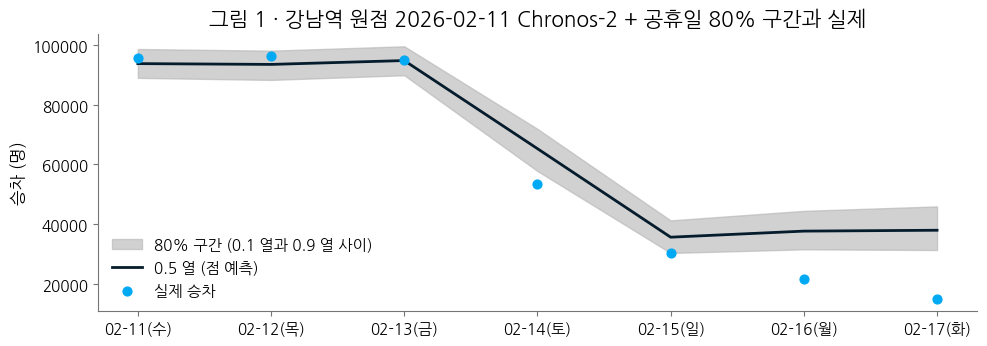

In [2]:
# 오늘의 준비 — 읽고 실행만 합니다
#  서울 지하철 100개 역에 Chronos-2 두 모델로 원점 5개를 예측해 표 1 · 표 2 · 그림 1 · 표 3 을 만듭니다 (T4 약 20초, CPU 약 100초)
#  Chronos-2 를 불러오다 내려받기 오류(Hugging Face)가 나면 맨 위 설치 셀부터 다시 실행합니다
import os, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 지금까지와 같은 손질 — 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]
MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)       # 행렬 열의 날짜
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]   # 행렬 행의 역 이름

H, CTX = 7, 512                               # 채점 7일 · Chronos-2 에 주는 과거 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # 분위수 아홉 열 (80% 구간의 두 끝 = 0.1 열 · 0.9 열)
ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]   # 예측 원점 5개 (수요일)
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]              # 공휴일 없는 두 주: 채점 7일에 평일 공휴일이 없다
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]  # 공휴일 있는 세 주: 채점 7일에 평일 공휴일이 있다
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # 맨 위 설치 셀과 같은 규칙 — 이 셀만 실행해도 정해집니다


def hol_flags(dates):
    """날짜마다 한국 공휴일이면 1, 아니면 0 (holidays 0.103 KR, 주말 공휴일 포함) — 달력이 정하는 값입니다"""
    import holidays
    di = pd.DatetimeIndex(dates)
    kr = holidays.KR(years=sorted(set(di.year)))
    return np.array([1.0 if d in kr else 0.0 for d in di])


HOL = hol_flags(DATES)                        # DATES 의 날마다 공휴일 1 / 0


def origin_ctx(origin):
    """원점 하나의 자료 — 원점의 열 번호(o), 원점 전날까지(hist), 채점 7일 실제(test, 명), 역별 MASE 분모(qden), 채점 7일 날짜(test_dates)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden, test_dates=DATES[o:o + H])


def chronos_frames(origin, holiday=True):
    """Chronos-2 의 predict_df 에 전달할 두 표 (df, future_df)

    df        : 100개 역 x 원점 전날까지 512일 — item_id(역 번호 0 ~ 99) · timestamp · target(승차, 명)
                · holiday(공휴일 1 / 0). holiday=False 면 holiday 열이 없습니다
    future_df : 100개 역 x 채점 7일 — item_id · timestamp · holiday(달력이 정한 공휴일). holiday=False 면 None
    """
    ctx = origin_ctx(origin)
    o, S = ctx["o"], MAT.shape[0]
    df = pd.DataFrame({"item_id": np.repeat(np.arange(S), CTX),
                       "timestamp": np.tile(DATES[o - CTX:o].values, S),
                       "target": MAT[:, o - CTX:o].ravel()})
    future_df = None
    if holiday:
        df["holiday"] = np.tile(HOL[o - CTX:o], S)
        future_df = pd.DataFrame({"item_id": np.repeat(np.arange(S), H),
                                  "timestamp": np.tile(ctx["test_dates"].values, S),
                                  "holiday": np.tile(HOL[o:o + H], S)})
    assert df["timestamp"].max() < pd.Timestamp(origin)   # 과거 표에는 원점 전날까지만
    return df, future_df


# Chronos-2 를 DEVICE 에 올립니다. 끊기면 세 번까지 다시 시도합니다
from chronos import BaseChronosPipeline
PIPE = None
for _try in range(1, 4):
    try:
        PIPE = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
        break
    except Exception as _e:
        print(f"Chronos-2 불러오기 {_try}번째 실패 : {type(_e).__name__}")
        time.sleep(5)
if PIPE is None:
    raise RuntimeError("Chronos-2 를 불러오지 못했습니다. 네트워크를 확인하고 이 셀을 다시 실행합니다")

# 원점 5개 x 두 모델(제로샷 · Chronos-2 + 공휴일)의 분위수 아홉 열을 얻어 파일로 남깁니다. 미션 준비 셀이 이 파일을 읽습니다
Y_TEST = {o: origin_ctx(o)["test"] for o in ORIGINS}      # 원점 → 100개 역 x 7일 실제 승차 (명)
Q_ZS, Q_HOL = {}, {}                                       # 원점 → 100개 역 x 7일 x 분위수 아홉 열 (명)
for _holiday, _path, _store in ((False, "c2_zs_q.parquet", Q_ZS), (True, "c2_hol_q.parquet", Q_HOL)):
    _frames = []
    for o in ORIGINS:
        _df, _future = chronos_frames(o, holiday=_holiday)
        _fc = PIPE.predict_df(_df, future_df=_future, prediction_length=H, quantile_levels=QS)
        _fc = _fc.sort_values(["item_id", "timestamp"])
        _store[o] = np.stack([_fc[str(t)].to_numpy().reshape(-1, H) for t in QS], axis=-1)
        _frames.append(_fc.assign(origin=o)[["origin", "item_id", "timestamp"] + [str(t) for t in QS]])
    pd.concat(_frames, ignore_index=True).to_parquet(_path)

# 표 1: 원점마다 채점 7일에 있는 평일(월~금) 공휴일
DAY_KO = "월화수목금토일"
WDH_TABLE = {}
for o in ORIGINS:
    _c = origin_ctx(o)
    WDH_TABLE[o] = [f"{d:%m-%d}({DAY_KO[d.dayofweek]})" for d, h in zip(_c["test_dates"], HOL[_c["o"]:_c["o"] + H])
                    if h == 1 and d.dayofweek < 5]
print("표 1 · 채점 7일의 평일 공휴일 (원점 5개)")
for o in ORIGINS:
    _group = "공휴일 없는 주" if o in PLAIN_ORIGINS else "공휴일 있는 주"
    print(f"  {o} · {_group} : {' · '.join(WDH_TABLE[o]) or '없음'}")
print("  주말 공휴일 2025-10-05(일, 추석 연휴)는 평일 공휴일로 세지 않습니다")

# 표 2: 강남역, 원점 2026-06-24 의 첫 사흘. Chronos-2 + 공휴일 분위수 아홉 열과 실제 승차
GN = STATIONS.index("2호선 강남")
_d = origin_ctx("2026-06-24")["test_dates"][:3]
GN_Q = pd.DataFrame(Q_HOL["2026-06-24"][GN, :3], index=[f"{d:%Y-%m-%d}" for d in _d], columns=[str(t) for t in QS])
GN_Q["실제"] = Y_TEST["2026-06-24"][GN, :3]
print("\n표 2 · 강남역 원점 2026-06-24 Chronos-2 + 공휴일 분위수 아홉 열과 실제 (명)")
print(GN_Q.round(0).astype(int).to_string())

# 그림 1: 강남역, 원점 2026-02-11 (설 연휴가 있는 주). 0.1 열과 0.9 열 사이를 칠하고 실제 승차를 점으로
_d = origin_ctx("2026-02-11")["test_dates"]
GN_SEOL = pd.DataFrame(Q_HOL["2026-02-11"][GN][:, [0, 4, 8]], columns=["0.1", "0.5", "0.9"],
                       index=[f"{d:%m-%d}({DAY_KO[d.dayofweek]})" for d in _d])
GN_SEOL["실제"] = Y_TEST["2026-02-11"][GN]
fig, ax = plt.subplots(figsize=(10, 3.6))
_x = np.arange(H)
ax.fill_between(_x, GN_SEOL["0.1"], GN_SEOL["0.9"], color="#B3B3B3", alpha=0.6, label="80% 구간 (0.1 열과 0.9 열 사이)")
ax.plot(_x, GN_SEOL["0.5"], color="#051C2C", lw=2, label="0.5 열 (점 예측)")
ax.scatter(_x, GN_SEOL["실제"], color="#00A9F4", s=40, zorder=3, label="실제 승차")
ax.set_xticks(_x, GN_SEOL.index)
ax.set_ylabel("승차 (명)")
ax.set_title("그림 1 · 강남역 원점 2026-02-11 Chronos-2 + 공휴일 80% 구간과 실제")
ax.legend(loc="lower left", frameon=False)
plt.show()

# 표 3: 제로샷 80% 구간의 포함률을 원점마다 구해 공휴일 없는 두 주와 공휴일 있는 세 주로 평균
_cov = {o: ((Y_TEST[o] >= Q_ZS[o][..., 0]) & (Y_TEST[o] <= Q_ZS[o][..., -1])).mean() * 100 for o in ORIGINS}
COV_ZS = {"공휴일 없는 두 주": np.mean([_cov[o] for o in PLAIN_ORIGINS]),
          "공휴일 있는 세 주": np.mean([_cov[o] for o in HOL_ORIGINS]),
          "원점 5개": np.mean([_cov[o] for o in ORIGINS])}
print("표 3 · 제로샷 80% 구간의 포함률, 공휴일이 있는 주와 없는 주 (%)")
for _k, _v in COV_ZS.items():
    print(f"  {_k:<9} {_v:5.1f}")

## 분위수와 포함률 확인

> **[문제] 0.9 열에 맞춘 인력이 모자랄 확률**
>
> 예를 들어 다음 주 수요일 어느 역의 0.1 열이 8만 명, 0.9 열이 10만 명일 때 10만 명에 맞춰 인력을 두면 인력이 모자랄 확률은 얼마일까요?
>
> 1. 약 10%
> 2. 약 20%
> 3. 약 90%

> **[문제] 인력 계획에 전달할 80% 구간**
>
> 예를 들어 같은 주에 구간 A 는 700점에서 구한 포함률이 90% 이고 평균 길이가 4,000명입니다. 구간 B 는 포함률이 80% 이고 평균 길이가 2,500명입니다. 「80% 구간」이라는 이름으로 인력 계획에 전달할 구간은 어느 쪽일까요?
>
> 1. A. 더 많이 담았으니 80% 구간으로 더 믿을 만하다
> 2. B. 명목 80% 에 맞게 담으면서 구간이 짧다
> 3. 어느 쪽이든 같다. 포함률 10%p 차이는 흔들림이다

## 서울 지하철 100개 역으로 판단하기

아래 세 문항은 「오늘의 준비」 셀 출력을 읽고 답합니다. 표 2 와 그림 1 은 강남역 한 역의 두 주입니다. 표 3 은 100개 역 700점의 포함률을 원점마다 구해 공휴일 없는 두 주와 공휴일 있는 세 주로 평균한 제로샷의 값입니다.

> **[문제] 강남역 6월 25일 80% 구간 길이**
>
> 「오늘의 준비」 셀을 실행하면 나오는 「표 2 · 강남역 원점 2026-06-24 Chronos-2 + 공휴일 분위수 아홉 열과 실제 (명)」을 봅니다. 2026-06-25 행의 80% 구간 길이는 약 몇 명일까요?
>
> 1. 약 3,600명
> 2. 약 93,000명
> 3. 약 5,700명

> **[문제] 설 연휴가 있는 주 구간 밖으로 나간 날**
>
> 「오늘의 준비」 셀을 실행하면 나오는 「그림 1 · 강남역 원점 2026-02-11 Chronos-2 + 공휴일 80% 구간과 실제」를 봅니다. 구간 밖으로 나간 날의 실제 승차는 구간의 어느 쪽에 있나요?
>
> 1. 모두 아래 끝보다 적었다
> 2. 모두 위 끝보다 많았다
> 3. 아래와 위 양쪽으로 나갔다

> **[문제] 제로샷 구간을 평일 공휴일이 있는 주 인력에**
>
> 「오늘의 준비」 셀을 실행하면 나오는 「표 3 · 제로샷 80% 구간의 포함률, 공휴일이 있는 주와 없는 주 (%)」을 봅니다. 평일 공휴일이 있는 주의 인력 계획에 제로샷 80% 구간을 넘겨도 될까요?
>
> 1. 넘긴다. 공휴일 없는 두 주에서 80% 를 넘게 담았다
> 2. 넘기지 않는다. 공휴일 있는 세 주에서 절반도 담지 못했다
> 3. 넘긴다. 원점 5개를 합치면 명목 80% 에 가깝다

## 미션 1 — Chronos-2 + 공휴일의 80% 포함률

표 3 에서 제로샷 구간은 공휴일 있는 세 주 2,100점에서 포함률이 41.6% 였습니다. 공휴일 열을 입력한 Chronos-2 + 공휴일 구간의 포함률을 같은 방법으로 구해, 두 주와 세 주의 값을 명목 80% 와 비교합니다.

#### 할 일 — 미션 1 (25분)

1. 아래 「미션 1 준비 셀」을 실행합니다. 이 셀은 고치지 않습니다.
2. 아래 「만들 것」대로 시킬 일을 「PROMPT 셀」의 `PROMPT = """ """` 따옴표 안에 내 말로 적습니다. 예시 프롬프트도 따옴표 안에 붙여 넣어야 채점됩니다.
3. 셀을 선택한 채로 AI 튜터에게 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶ 합니다. LMS 밖이면 받은 코드를 AI 코드 표시선(`# --- 여기부터 AI 코드 ---`) 아래에 둡니다.
4. 채점 결과를 봅니다. ❌ 면 힌트대로 PROMPT 를 고쳐 3번부터 다시 합니다.

**이 미션의 질문**: Chronos-2 + 공휴일의 80% 구간은 공휴일 없는 두 주와 공휴일 있는 세 주에서 포함률이 각각 몇 % 일까요?

**쓸 수 있는 것**: 「미션 1 준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 |
|---|---|
| `Q_HOL` | 원점 → Chronos-2 + 공휴일 분위수 배열(100개 역 × 7일 × 9열, 명). `[..., 0]` 이 0.1 열, `[..., -1]` 이 0.9 열 |
| `Y_TEST` | 원점 → 채점 7일 실제 승차(100개 역 × 7일, 명) |
| `ORIGINS` · `PLAIN_ORIGINS` · `HOL_ORIGINS` | 원점 5개 · 공휴일 없는 두 주의 원점 2개 · 공휴일 있는 세 주의 원점 3개(날짜 문자열 목록) |
| `QS` | 분위수 아홉 개 `[0.1, 0.2, …, 0.9]` |
| `COL` · `FIG_W` | 그래프 색 사전과 그림 가로 크기(설치 셀) |

#### 만들 것

1·2번의 굵은 이름은 채점이 출력에서 찾으니 글자 그대로 쓰고, 3·4번의 굵은 말은 만들 것의 이름이라 출력에 쓰지 않아도 됩니다. 모두 「PROMPT 셀」에서 출력합니다.

1. **공휴일 없는 두 주 포함률**: 단위 % · 소수 첫째 자리. 원점마다 700점 가운데 실제가 0.1 열 이상 0.9 열 이하인 점의 비율을 구해 `PLAIN_ORIGINS` 두 원점으로 평균합니다
2. **공휴일 있는 세 주 포함률**: 단위 % · 소수 첫째 자리. 같은 방법으로 `HOL_ORIGINS` 세 원점을 평균합니다
3. **원점별 대조 행**: 원점마다 구간 안·아래·위의 점 수를 한 행씩 찍습니다. 세 수를 더해 700 이 되는지 대조하는 행이고, 채점하지 않습니다
4. **그래프 한 장**: 종류는 자유이고 가로축 「예측 원점」, 세로축 「포함률 (%)」 이름을 답니다. 권장은 원점 5개의 포함률 막대에 두 주와 세 주를 다른 색으로, 80% 높이에 가로 점선입니다

**통과 기준**: 1·2번 값이 「이름 = 값 %」 한 행씩 있고 기준 범위 안이며, 그래프에 가로축·세로축 이름이 있으면 통과입니다.

#### 프롬프트에 넣을 것(힌트)

- **고정할 이름**: 위 표의 이름은 다시 만들지 말라고 적습니다.
- **구간의 두 끝**: 아래 끝은 0.1 열 `Q_HOL[원점][..., 0]`, 위 끝은 0.9 열 `Q_HOL[원점][..., -1]` 입니다. 끝과 같은 값도 안으로 세도록 `>=`·`<=` 두 조건을 `&` 로 묶으라고 적습니다.
- **평균하는 순서**: 원점 5개의 포함률을 먼저 구한 뒤, 두 주와 세 주를 따로 평균하라고 적습니다.
- **출력 형식**: 1·2번의 이름·단위·자릿수를 그대로 옮겨 적습니다.

<details class="lms-extra"><summary>자세히 — 예시 프롬프트</summary>

Q_HOL, Y_TEST, ORIGINS, PLAIN_ORIGINS, HOL_ORIGINS 와 설치 셀의 FIG_W, COL 은 이미 있으니 다시 만들지 마. ORIGINS 원점 5개마다 Y_TEST 가 Q_HOL 의 [..., 0] 이상이고 [..., -1] 이하인 점을 세어, 구간 안·아래·위 점 수와 포함률(%)을 원점마다 한 행씩 찍어 줘. 원점별 포함률을 PLAIN_ORIGINS 와 HOL_ORIGINS 로 나눠 평균하고 "공휴일 없는 두 주 포함률 = 값 %" 와 "공휴일 있는 세 주 포함률 = 값 %" 를 소수 첫째 자리로 한 행씩 출력해 줘. 원점 5개의 포함률 막대를 공휴일이 있는 주와 없는 주가 다른 색이 되게 그리고, 80% 에 가로 점선과 가로축 "예측 원점", 세로축 "포함률 (%)" 을 달아 줘.

</details>

<details class="lms-extra"><summary>배경 — 구간 안의 점과 밖의 점</summary>

<img src="https://scikit-learn.org/stable/_images/sphx_glr_plot_quantile_regression_002.png" alt="분위수 선 세 개와 점을 그린 산점도. 두 바깥 선 사이의 점은 회색 원, 밖의 점은 더하기 표시" width="480" height="360"/>
<p align="center"><em>▲ 분위수 두 선 사이에 있는 점과 벗어난 점. 가로축은 입력 x, 세로축은 예측하려는 값 y 다. 파란 선이 0.05 분위수, 초록 선이 0.95 분위수이고 두 선 사이(90% 구간)에 있는 점은 회색 원, 벗어난 점은 + 로 찍었다. 포함률은 회색 원의 수를 전체 점 수로 나눈 값이다 (출처: scikit-learn 공식 문서, Quantile regression 예제)</em></p>

</details>

#### 예상 적기

> **[예측] 공휴일 있는 세 주 포함률은 공휴일 없는 두 주보다 높을까요, 낮을까요?**
>
> 1. 높다. 공휴일 열을 입력해 평일 공휴일이 있는 주의 포함률이 더 높다
> 2. 비슷하다. 공휴일이 있는 주와 없는 주 모두 포함률이 명목 80% 에 가깝다
> 3. 낮다. 평일 공휴일이 있는 주에는 여전히 벗어나는 점이 많다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

<details class="lms-extra"><summary>예상 확인 — 미션 1 결과를 본 뒤 펼칩니다</summary>

답은 셋째 보기입니다. 포함률은 공휴일 없는 두 주 79.5%, 공휴일 있는 세 주 66.4% 이고, 공휴일 있는 세 주는 명목 80% 보다 80 − 66.4 = 13.6%p 모자랍니다. 원점별로는 2025-08-13 78.9%, 2025-10-01 61.4%, 2026-02-11 59.0% 라, 평일 공휴일이 하루인 원점 2025-08-13(공휴일 있는 주)만 명목 80% 에 가깝습니다.

- 「높다」: 공휴일 열을 입력하자 제로샷의 41.6% 가 66.4% 로 높아졌지만, 공휴일 없는 두 주의 79.5% 에는 못 미칩니다.
- 「비슷하다」: 포함률이 명목 80% 에 가까운 것은 공휴일 없는 두 주뿐입니다.

</details>

In [3]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 이름을 직접 만듭니다
#  「오늘의 준비」 셀이 남긴 분위수 파일을 읽고, 파일이 없으면 Chronos-2 로 다시 예측합니다 (T4 약 10초)
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 지금까지와 같은 손질 — 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]
MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)       # 행렬 열의 날짜
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]   # 행렬 행의 역 이름

H, CTX = 7, 512                               # 채점 7일 · Chronos-2 에 주는 과거 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # 분위수 아홉 열 (80% 구간의 두 끝 = 0.1 열 · 0.9 열)
ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]   # 예측 원점 5개 (수요일)
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]              # 공휴일 없는 두 주: 채점 7일에 평일 공휴일이 없다
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]  # 공휴일 있는 세 주: 채점 7일에 평일 공휴일이 있다
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # 맨 위 설치 셀과 같은 규칙 — 이 셀만 실행해도 정해집니다


def hol_flags(dates):
    """날짜마다 한국 공휴일이면 1, 아니면 0 (holidays 0.103 KR, 주말 공휴일 포함) — 달력이 정하는 값입니다"""
    import holidays
    di = pd.DatetimeIndex(dates)
    kr = holidays.KR(years=sorted(set(di.year)))
    return np.array([1.0 if d in kr else 0.0 for d in di])


HOL = hol_flags(DATES)                        # DATES 의 날마다 공휴일 1 / 0


def origin_ctx(origin):
    """원점 하나의 자료 — 원점의 열 번호(o), 원점 전날까지(hist), 채점 7일 실제(test, 명), 역별 MASE 분모(qden), 채점 7일 날짜(test_dates)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden, test_dates=DATES[o:o + H])


def chronos_frames(origin, holiday=True):
    """Chronos-2 의 predict_df 에 전달할 두 표 (df, future_df)

    df        : 100개 역 x 원점 전날까지 512일 — item_id(역 번호 0 ~ 99) · timestamp · target(승차, 명)
                · holiday(공휴일 1 / 0). holiday=False 면 holiday 열이 없습니다
    future_df : 100개 역 x 채점 7일 — item_id · timestamp · holiday(달력이 정한 공휴일). holiday=False 면 None
    """
    ctx = origin_ctx(origin)
    o, S = ctx["o"], MAT.shape[0]
    df = pd.DataFrame({"item_id": np.repeat(np.arange(S), CTX),
                       "timestamp": np.tile(DATES[o - CTX:o].values, S),
                       "target": MAT[:, o - CTX:o].ravel()})
    future_df = None
    if holiday:
        df["holiday"] = np.tile(HOL[o - CTX:o], S)
        future_df = pd.DataFrame({"item_id": np.repeat(np.arange(S), H),
                                  "timestamp": np.tile(ctx["test_dates"].values, S),
                                  "holiday": np.tile(HOL[o:o + H], S)})
    assert df["timestamp"].max() < pd.Timestamp(origin)   # 과거 표에는 원점 전날까지만
    return df, future_df


def load_quantiles(path, holiday):
    """분위수 파일(origin · item_id · timestamp · "0.1"~"0.9")을 원점 → 100 x 7 x 9 배열로 읽습니다.
    「오늘의 준비」 셀이 남긴 파일이 없으면 Chronos-2 로 원점 5개를 예측해 그 파일을 만듭니다"""
    if not os.path.exists(path):
        from chronos import BaseChronosPipeline
        pipe = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
        frames = []
        for o in ORIGINS:
            df, future_df = chronos_frames(o, holiday=holiday)
            fc = pipe.predict_df(df, future_df=future_df, prediction_length=H, quantile_levels=QS)
            frames.append(fc.assign(origin=o)[["origin", "item_id", "timestamp"] + [str(t) for t in QS]])
        pd.concat(frames, ignore_index=True).to_parquet(path)
    d = pd.read_parquet(path).sort_values(["origin", "item_id", "timestamp"])
    return {o: np.stack([g[str(t)].to_numpy().reshape(-1, H) for t in QS], axis=-1)
            for o, g in d.groupby("origin")}


Y_TEST = {o: origin_ctx(o)["test"] for o in ORIGINS}       # 원점 → 100개 역 x 7일 실제 승차 (명)
Q_HOL = load_quantiles("c2_hol_q.parquet", holiday=True)   # 원점 → Chronos-2 + 공휴일 100개 역 x 7일 x 9열 (명)

print(f"자료 : 100개 역 x {MAT.shape[1]:,}일 승차 · 원점 5개 = 공휴일 없는 두 주 {' · '.join(PLAIN_ORIGINS)}"
      f" + 공휴일 있는 세 주 {' · '.join(HOL_ORIGINS)}")
print(f"Q_HOL : 원점마다 {Q_HOL[ORIGINS[0]].shape} (100개 역 x 7일 x 분위수 아홉 열, 명) · "
      f"Y_TEST : 원점마다 {Y_TEST[ORIGINS[0]].shape} (100개 역 x 7일, 명)")
print("쓸 수 있는 이름 : Q_HOL · Y_TEST · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · QS (설치 셀의 COL · FIG_W 도 씁니다)")

자료 : 100개 역 x 4,199일 승차 · 원점 5개 = 공휴일 없는 두 주 2025-12-10 · 2026-06-24 + 공휴일 있는 세 주 2025-08-13 · 2025-10-01 · 2026-02-11
Q_HOL : 원점마다 (100, 7, 9) (100개 역 x 7일 x 분위수 아홉 열, 명) · Y_TEST : 원점마다 (100, 7) (100개 역 x 7일, 명)
쓸 수 있는 이름 : Q_HOL · Y_TEST · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · QS (설치 셀의 COL · FIG_W 도 씁니다)


원점          묶음             안    아래     위    합계    포함률(%)
2025-08-13  공휴일 있음       552   120    28   700     78.9%
2025-10-01  공휴일 있음       430   142   128   700     61.4%
2025-12-10  공휴일 없음       559    13   128   700     79.9%
2026-02-11  공휴일 있음       413   262    25   700     59.0%
2026-06-24  공휴일 없음       554     9   137   700     79.1%

공휴일 없는 두 주 포함률 = 79.5%
공휴일 있는 세 주 포함률 = 66.4%
참고: 공휴일 없는 두 주는 명목 80% 대비 -0.5%p
참고: 공휴일 있는 세 주는 명목 80% 대비 -13.6%p

──────────────────────────────────────────────────────
◼ 미션 1 채점 결과
✅ 공휴일 없는 두 주 포함률 — 출력에서 찾은 값: 79.5
✅ 공휴일 있는 세 주 포함률 — 출력에서 찾은 값: 66.4
✅ 그래프 — 그림이 있고 가로축·세로축 이름이 있습니다
──────────────────────────────────────────────────────


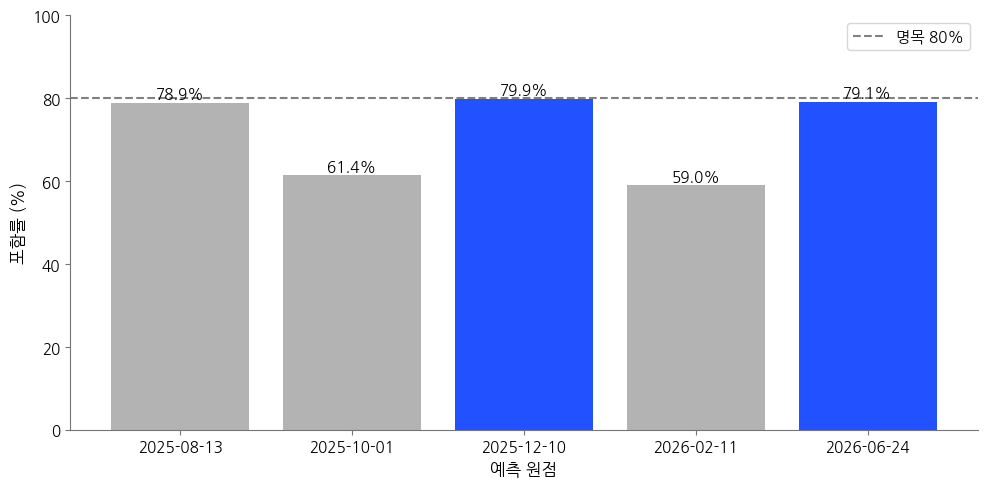

In [4]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → AI 튜터에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
# 시킬 일은 AI 튜터 대화창이 아니라 아래 따옴표 안에 적습니다. 예시 프롬프트도 따옴표 안에 붙여 넣어야 채점됩니다
PROMPT = """
미션 1 준비 셀이 만든 이름(Q_HOL, Y_TEST, ORIGINS, PLAIN_ORIGINS, HOL_ORIGINS, QS, COL, FIG_W)은 다시 만들거나 덮어쓰지 말고 그대로 써.

1. ORIGINS 의 원점 5개마다 포함률을 먼저 구해.
   - 아래 끝 lo = Q_HOL[원점][..., 0] (0.1 열), 위 끝 hi = Q_HOL[원점][..., -1] (0.9 열), 실제 y = Y_TEST[원점]. 셋 다 (100개 역 × 7일) 배열이다.
   - 구간 안 = (y >= lo) & (y <= hi). 끝과 같은 값도 안으로 센다.
   - 아래 = y < lo, 위 = y > hi.
   - 원점 포함률 = 구간 안 점 수 ÷ 700 × 100 (%).

2. 원점별 대조 행: 원점마다 한 행씩 「원점, 묶음(공휴일 없음/있음), 안 n, 아래 n, 위 n, 합계 n, 포함률 %」를 출력해. 합계가 700 인지 확인할 수 있게 해.

3. 원점 5개의 포함률을 다 구한 뒤에 묶음별로 따로 평균해. PLAIN_ORIGINS 두 원점과 HOL_ORIGINS 세 원점을 각각 평균한다.

4. 출력: 아래 두 줄을 이 이름 그대로, 단위 %, 소수 첫째 자리로 출력해.
   - 공휴일 없는 두 주 포함률 = 값 %
   - 공휴일 있는 세 주 포함률 = 값 %
   그 밑에 참고로 두 값이 명목 80% 와 몇 %p 차이 나는지 한 줄씩 적어.

5. 그래프 한 장: 원점 5개의 포함률 막대그래프. PLAIN_ORIGINS 원점과 HOL_ORIGINS 원점은 COL 의 서로 다른 색으로 칠하고, 80% 높이에 가로 점선(명목 80%)을 긋고, 막대 위에 포함률 값을 적어. 가로축 이름은 「예측 원점」, 세로축 이름은 「포함률 (%)」, 세로축 범위는 0~100. 가로 크기는 FIG_W 를 써.
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import matplotlib.pyplot as plt

rows = []
rates = {}
for origin in ORIGINS:
    lo = Q_HOL[origin][..., 0]
    hi = Q_HOL[origin][..., -1]
    y = Y_TEST[origin]

    inside = (y >= lo) & (y <= hi)
    below = y < lo
    above = y > hi

    n_in = int(inside.sum())
    n_below = int(below.sum())
    n_above = int(above.sum())
    n_total = n_in + n_below + n_above

    group = "공휴일 없음" if origin in PLAIN_ORIGINS else "공휴일 있음"
    rate = n_in / 700 * 100
    rates[origin] = rate

    rows.append((origin, group, n_in, n_below, n_above, n_total, rate))

print(f"{'원점':<12}{'묶음':<10}{'안':>6}{'아래':>6}{'위':>6}{'합계':>6}{'포함률(%)':>10}")
for origin, group, n_in, n_below, n_above, n_total, rate in rows:
    print(f"{origin:<12}{group:<10}{n_in:>6}{n_below:>6}{n_above:>6}{n_total:>6}{rate:>9.1f}%")

plain_rate = np.mean([rates[o] for o in PLAIN_ORIGINS])
hol_rate = np.mean([rates[o] for o in HOL_ORIGINS])

print(f"\n공휴일 없는 두 주 포함률 = {plain_rate:.1f}%")
print(f"공휴일 있는 세 주 포함률 = {hol_rate:.1f}%")
print(f"참고: 공휴일 없는 두 주는 명목 80% 대비 {plain_rate - 80:+.1f}%p")
print(f"참고: 공휴일 있는 세 주는 명목 80% 대비 {hol_rate - 80:+.1f}%p")

fig, ax = plt.subplots(figsize=(FIGW, 5))
colors = [COL["파랑"] if o in PLAIN_ORIGINS else COL["연회색"] for o in ORIGINS]
bars = ax.bar(ORIGINS, [rates[o] for o in ORIGINS], color=colors)
ax.axhline(80, linestyle="--", color="gray", label="명목 80%")
for b, o in zip(bars, ORIGINS):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1,
             f"{rates[o]:.1f}%", ha="center")
ax.set_xlabel("예측 원점")
ax.set_ylabel("포함률 (%)")
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

## 미션 2 — 제로샷과 Chronos-2 + 공휴일의 구간 길이

포함률은 구간을 넓히기만 해도 오릅니다. Chronos-2 + 공휴일의 공휴일 있는 세 주 포함률이 제로샷보다 높은 것(41.6% 대 66.4%)이 구간을 넓혀서인지 평균 구간 길이로 확인합니다. 미션 1 과 같은 순서로 합니다.

시킬 일은 미션 1 처럼 「PROMPT 셀」의 `PROMPT = """ """` 따옴표 안에 적습니다. 따옴표 안이 비어 있으면 채점과 완성본 풀이가 잠깁니다.

**이 미션의 질문**: Chronos-2 + 공휴일의 공휴일 있는 세 주 포함률이 제로샷보다 높은 것은 구간을 넓혀서일까요?

**쓸 수 있는 것**: 「미션 2 준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 |
|---|---|
| `Q_ZS` · `Q_HOL` | 원점 → 제로샷 · Chronos-2 + 공휴일의 분위수 배열(100개 역 × 7일 × 9열, 명) |
| `Y_TEST` | 원점 → 채점 7일 실제 승차(100개 역 × 7일, 명) |
| `ORIGINS` · `PLAIN_ORIGINS` · `HOL_ORIGINS` · `QS` | 미션 1 과 같은 원점 목록과 분위수 아홉 개 |
| `COL` · `FIG_W` | 그래프 색 사전과 그림 가로 크기(설치 셀) |

#### 만들 것

굵은 이름은 채점이 찾으니 글자 그대로 쓰고, 모두 「PROMPT 셀」에서 출력합니다.

1. **Chronos-2 + 공휴일의 공휴일 있는 세 주 평균 구간 길이**: 단위 명 · 정수. 구간 길이는 역·날마다 0.9 열에서 0.1 열을 뺀 값입니다. 원점마다 700점으로 평균한 뒤 `HOL_ORIGINS` 세 원점을 평균합니다. 천 명으로 나누지 않고 명 단위 그대로 적습니다
2. **공휴일 있는 세 주 구간 길이 비**: 단위 배 · 소수 둘째 자리. 공휴일 있는 세 주에서 Chronos-2 + 공휴일의 평균 구간 길이를 제로샷의 값으로 나눕니다
3. **그래프 한 장**: 종류는 자유이고 가로축 「채점한 주」, 세로축 「평균 구간 길이 (명)」 이름을 답니다. 권장은 공휴일 유무 × 두 모델의 막대 4개에 범례 두 모델입니다

**통과 기준**: 1·2번 값이 「이름 = 값 단위」 한 행씩 있고 기준 범위 안이며, 그래프에 가로축·세로축 이름이 있으면 통과입니다.

#### 프롬프트에 넣을 것(힌트)

- **구간 길이**: `q[..., -1] - q[..., 0]`(0.9 열 − 0.1 열)을 원점마다 평균한 뒤 공휴일 없는 두 주와 공휴일 있는 세 주로 나눠 평균하라고 적습니다. 빼는 순서가 거꾸로면 음수가 나옵니다.
- **비의 방향**: Chronos-2 + 공휴일을 제로샷으로 나눈다고 분자와 분모를 적습니다.
- **평균할 원점**: 두 값 모두 공휴일 있는 세 주의 원점 3개로만 평균하라고 적습니다.
- **막대 차례**: 두 주와 세 주마다 두 모델의 막대를 나란히 두라고 적습니다.

<details class="lms-extra"><summary>배경 — 80% 구간과 95% 구간의 길이</summary>

<img src="https://otexts.com/fpp3/fpp_files/figure-html/googforecasts2-1.png" alt="구글 일별 종가 선 그래프 끝에 오른쪽으로 갈수록 넓어지는 두 겹의 예측구간을 칠한 그림" width="600" height="330"/>
<p align="center"><em>▲ 구글 일별 종가의 나이브 예측과 두 예측구간. 진한 파란 영역이 80% 구간, 연한 영역이 95% 구간이다. 명목 포함률을 높이면 구간이 길어지고, 며칠 뒤를 예측할수록 두 구간 모두 길어진다 (출처: Hyndman &amp; Athanasopoulos, Forecasting: Principles and Practice 3판, 그림 5.14)</em></p>

</details>

#### 예상 적기

> **[예측] 공휴일 있는 세 주에서 Chronos-2 + 공휴일 구간은 제로샷보다 길까요?**
>
> 1. 길다. 평일 공휴일이 있는 주에는 승차가 얼마나 줄지 몰라 구간을 넓힌다
> 2. 비슷하다. 같은 Chronos-2 라 구간 길이도 비슷하다
> 3. 짧다. 공휴일 열을 받아 예측이 더 정확해진다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

<details class="lms-extra"><summary>예상 확인 — 미션 2 결과를 본 뒤 펼칩니다</summary>

답은 첫째 보기입니다. 공휴일 있는 세 주에서 Chronos-2 + 공휴일의 평균 구간 길이는 5,734명으로, 제로샷 3,768명의 5,734 ÷ 3,768 = 1.52배입니다. 원점별로는 2025-08-13 1.13배, 2025-10-01 1.63배, 2026-02-11 1.92배입니다. 1.52배는 세 주 평균끼리 나눈 값이라, 원점별 비 셋의 평균 1.56 과 조금 다릅니다.

- 「비슷하다」: 두 모델의 구간 길이가 비슷한 것은 공휴일 없는 두 주(2,839명 대 3,082명, 0.92배)입니다.
- 「짧다」: 0.92배로 조금 짧아진 것도 공휴일 없는 두 주입니다. 평일 공휴일에 승차가 얼마나 줄지는 날과 역마다 달라, 공휴일 있는 세 주에서는 구간이 길어졌습니다.

그래서 공휴일 있는 세 주의 66.4% 는 구간을 1.52배로 넓혀 얻은 값이고, 넓힌 구간으로도 명목 80% 에는 못 미칩니다.

</details>

In [5]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 이름을 직접 만듭니다
#  「오늘의 준비」 셀이 남긴 두 모델의 분위수 파일을 읽고, 파일이 없으면 Chronos-2 로 다시 예측합니다 (T4 약 20초)
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 지금까지와 같은 손질 — 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]
MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)       # 행렬 열의 날짜
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]   # 행렬 행의 역 이름

H, CTX = 7, 512                               # 채점 7일 · Chronos-2 에 주는 과거 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # 분위수 아홉 열 (80% 구간의 두 끝 = 0.1 열 · 0.9 열)
ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]   # 예측 원점 5개 (수요일)
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]              # 공휴일 없는 두 주: 채점 7일에 평일 공휴일이 없다
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]  # 공휴일 있는 세 주: 채점 7일에 평일 공휴일이 있다
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # 맨 위 설치 셀과 같은 규칙 — 이 셀만 실행해도 정해집니다


def hol_flags(dates):
    """날짜마다 한국 공휴일이면 1, 아니면 0 (holidays 0.103 KR, 주말 공휴일 포함) — 달력이 정하는 값입니다"""
    import holidays
    di = pd.DatetimeIndex(dates)
    kr = holidays.KR(years=sorted(set(di.year)))
    return np.array([1.0 if d in kr else 0.0 for d in di])


HOL = hol_flags(DATES)                        # DATES 의 날마다 공휴일 1 / 0


def origin_ctx(origin):
    """원점 하나의 자료 — 원점의 열 번호(o), 원점 전날까지(hist), 채점 7일 실제(test, 명), 역별 MASE 분모(qden), 채점 7일 날짜(test_dates)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden, test_dates=DATES[o:o + H])


def chronos_frames(origin, holiday=True):
    """Chronos-2 의 predict_df 에 전달할 두 표 (df, future_df)

    df        : 100개 역 x 원점 전날까지 512일 — item_id(역 번호 0 ~ 99) · timestamp · target(승차, 명)
                · holiday(공휴일 1 / 0). holiday=False 면 holiday 열이 없습니다
    future_df : 100개 역 x 채점 7일 — item_id · timestamp · holiday(달력이 정한 공휴일). holiday=False 면 None
    """
    ctx = origin_ctx(origin)
    o, S = ctx["o"], MAT.shape[0]
    df = pd.DataFrame({"item_id": np.repeat(np.arange(S), CTX),
                       "timestamp": np.tile(DATES[o - CTX:o].values, S),
                       "target": MAT[:, o - CTX:o].ravel()})
    future_df = None
    if holiday:
        df["holiday"] = np.tile(HOL[o - CTX:o], S)
        future_df = pd.DataFrame({"item_id": np.repeat(np.arange(S), H),
                                  "timestamp": np.tile(ctx["test_dates"].values, S),
                                  "holiday": np.tile(HOL[o:o + H], S)})
    assert df["timestamp"].max() < pd.Timestamp(origin)   # 과거 표에는 원점 전날까지만
    return df, future_df


def load_quantiles(path, holiday):
    """분위수 파일(origin · item_id · timestamp · "0.1"~"0.9")을 원점 → 100 x 7 x 9 배열로 읽습니다.
    「오늘의 준비」 셀이 남긴 파일이 없으면 Chronos-2 로 원점 5개를 예측해 그 파일을 만듭니다"""
    if not os.path.exists(path):
        from chronos import BaseChronosPipeline
        pipe = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
        frames = []
        for o in ORIGINS:
            df, future_df = chronos_frames(o, holiday=holiday)
            fc = pipe.predict_df(df, future_df=future_df, prediction_length=H, quantile_levels=QS)
            frames.append(fc.assign(origin=o)[["origin", "item_id", "timestamp"] + [str(t) for t in QS]])
        pd.concat(frames, ignore_index=True).to_parquet(path)
    d = pd.read_parquet(path).sort_values(["origin", "item_id", "timestamp"])
    return {o: np.stack([g[str(t)].to_numpy().reshape(-1, H) for t in QS], axis=-1)
            for o, g in d.groupby("origin")}


Y_TEST = {o: origin_ctx(o)["test"] for o in ORIGINS}       # 원점 → 100개 역 x 7일 실제 승차 (명)
Q_ZS = load_quantiles("c2_zs_q.parquet", holiday=False)    # 원점 → 제로샷 100개 역 x 7일 x 9열 (명)
Q_HOL = load_quantiles("c2_hol_q.parquet", holiday=True)   # 원점 → Chronos-2 + 공휴일 100개 역 x 7일 x 9열 (명)

print(f"자료 : 100개 역 x {MAT.shape[1]:,}일 승차 · 원점 5개 = 공휴일 없는 두 주 {' · '.join(PLAIN_ORIGINS)}"
      f" + 공휴일 있는 세 주 {' · '.join(HOL_ORIGINS)}")
print(f"Q_ZS · Q_HOL : 원점마다 {Q_HOL[ORIGINS[0]].shape} (100개 역 x 7일 x 분위수 아홉 열, 명) · "
      f"Y_TEST : 원점마다 {Y_TEST[ORIGINS[0]].shape} (100개 역 x 7일, 명)")
print("쓸 수 있는 이름 : Q_ZS · Q_HOL · Y_TEST · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · QS (설치 셀의 COL · FIG_W 도 씁니다)")

자료 : 100개 역 x 4,199일 승차 · 원점 5개 = 공휴일 없는 두 주 2025-12-10 · 2026-06-24 + 공휴일 있는 세 주 2025-08-13 · 2025-10-01 · 2026-02-11
Q_ZS · Q_HOL : 원점마다 (100, 7, 9) (100개 역 x 7일 x 분위수 아홉 열, 명) · Y_TEST : 원점마다 (100, 7) (100개 역 x 7일, 명)
쓸 수 있는 이름 : Q_ZS · Q_HOL · Y_TEST · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · QS (설치 셀의 COL · FIG_W 도 씁니다)


Chronos-2 + 공휴일의 공휴일 있는 세 주 평균 구간 길이 = 5734명
공휴일 있는 세 주 구간 길이 비 = 1.52배

참고: 원점별 평균 구간 길이 (명)
원점                   제로샷     Chronos-2+공휴일
2025-08-13          4017              4525
2025-10-01          4573              7476
2025-12-10          2701              2760
2026-02-11          2714              5202
2026-06-24          3462              2918

참고: 묶음 평균 구간 길이 (명)
제로샷 - 공휴일 없음 = 3082명
제로샷 - 공휴일 있음 = 3768명
Chronos-2 + 공휴일 - 공휴일 없음 = 2839명
Chronos-2 + 공휴일 - 공휴일 있음 = 5734명

참고: 공휴일 없는 두 주 구간 길이 비 = 0.92배

──────────────────────────────────────────────────────
◼ 미션 2 채점 결과
✅ Chronos-2 + 공휴일의 공휴일 있는 세 주 평균 구간 길이 — 출력에서 찾은 값: 5,734
✅ 공휴일 있는 세 주 구간 길이 비 — 출력에서 찾은 값: 1.52
✅ 그래프 — 그림이 있고 가로축·세로축 이름이 있습니다
──────────────────────────────────────────────────────


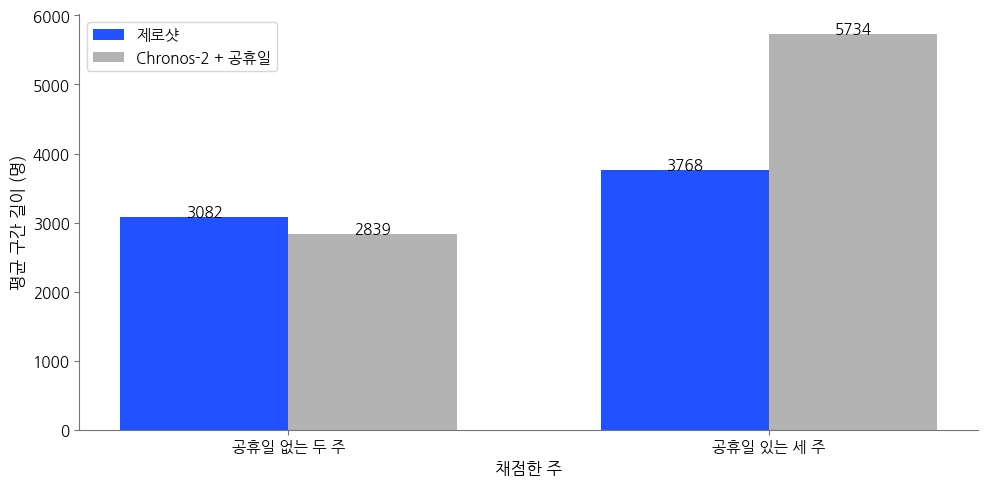

In [6]:
# 미션 2 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → AI 튜터에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
# 시킬 일은 AI 튜터 대화창이 아니라 아래 따옴표 안에 적습니다. 따옴표 안이 비어 있으면 채점과 완성본 풀이가 잠깁니다
PROMPT = """
미션 2 준비 셀이 만든 이름(Q_ZS, Q_HOL, Y_TEST, ORIGINS, PLAIN_ORIGINS, HOL_ORIGINS, QS, COL, FIG_W)은 다시 만들거나 덮어쓰지 말고 그대로 써.

1. 구간 길이 계산
   - 두 모델(제로샷 Q_ZS, Chronos-2 + 공휴일 Q_HOL) 각각, ORIGINS 의 원점 5개마다 구간 길이 = q[..., -1] - q[..., 0] (0.9 열 − 0.1 열, 순서 주의)를 (100개 역 × 7일) 로 구해.
   - 원점마다 700점의 구간 길이를 평균해서 원점별 평균 구간 길이를 먼저 저장해.
   - 그다음 PLAIN_ORIGINS 두 원점과 HOL_ORIGINS 세 원점을 따로 평균해서, 두 모델 × 두 묶음 = 4개의 평균 구간 길이를 만들어.

2. 비: 공휴일 있는 세 주에서 (Chronos-2 + 공휴일의 평균 구간 길이) ÷ (제로샷의 평균 구간 길이). 분자가 Chronos-2 + 공휴일, 분모가 제로샷이다. 두 값 모두 HOL_ORIGINS 세 원점으로만 평균한 값을 쓴다.

3. 출력: 아래 두 줄을 이 이름 그대로 출력해.
   - Chronos-2 + 공휴일의 공휴일 있는 세 주 평균 구간 길이 = 값 명   (정수, 천 명으로 나누지 않고 명 단위 그대로)
   - 공휴일 있는 세 주 구간 길이 비 = 값 배   (소수 둘째 자리)
   그 밑에 참고로 원점별 두 모델의 평균 구간 길이 표와, 4개 묶음 평균(정수, 명)을 출력하고, 공휴일 없는 두 주의 비(Chronos-2 + 공휴일 ÷ 제로샷)도 소수 둘째 자리로 한 줄 적어.

4. 그래프 한 장: 막대그래프. 가로축에 「공휴일 없는 두 주」, 「공휴일 있는 세 주」 두 묶음을 두고, 묶음마다 제로샷과 Chronos-2 + 공휴일 막대를 나란히 놓아(막대 4개). 범례에 두 모델 이름을 적고, 막대 위에 값(명)을 적어. 가로축 이름은 「채점한 주」, 세로축 이름은 「평균 구간 길이 (명)」. 색은 COL, 가로 크기는 FIG_W 를 써.
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import matplotlib.pyplot as plt

width = {}
for model_name, Q in [("제로샷", Q_ZS), ("Chronos-2 + 공휴일", Q_HOL)]:
    width[model_name] = {}
    for origin in ORIGINS:
        q = Q[origin]
        span = q[..., -1] - q[..., 0]
        width[model_name][origin] = span.mean()

group_width = {}
for model_name in width:
    plain_vals = [width[model_name][o] for o in PLAIN_ORIGINS]
    hol_vals = [width[model_name][o] for o in HOL_ORIGINS]
    group_width[model_name] = {
        "공휴일 없음": np.mean(plain_vals),
        "공휴일 있음": np.mean(hol_vals),
    }

chronos_hol_width = group_width["Chronos-2 + 공휴일"]["공휴일 있음"]
zs_hol_width = group_width["제로샷"]["공휴일 있음"]
ratio_hol = chronos_hol_width / zs_hol_width

chronos_plain_width = group_width["Chronos-2 + 공휴일"]["공휴일 없음"]
zs_plain_width = group_width["제로샷"]["공휴일 없음"]
ratio_plain = chronos_plain_width / zs_plain_width

print(f"Chronos-2 + 공휴일의 공휴일 있는 세 주 평균 구간 길이 = {chronos_hol_width:.0f}명")
print(f"공휴일 있는 세 주 구간 길이 비 = {ratio_hol:.2f}배")

print("\n참고: 원점별 평균 구간 길이 (명)")
print(f"{'원점':<12}{'제로샷':>12}{'Chronos-2+공휴일':>18}")
for origin in ORIGINS:
    print(f"{origin:<12}{width['제로샷'][origin]:>12.0f}{width['Chronos-2 + 공휴일'][origin]:>18.0f}")

print("\n참고: 묶음 평균 구간 길이 (명)")
for model_name in group_width:
    for group_name, val in group_width[model_name].items():
        print(f"{model_name} - {group_name} = {val:.0f}명")

print(f"\n참고: 공휴일 없는 두 주 구간 길이 비 = {ratio_plain:.2f}배")

labels = ["공휴일 없는 두 주", "공휴일 있는 세 주"]
zs_vals = [group_width["제로샷"]["공휴일 없음"], group_width["제로샷"]["공휴일 있음"]]
hol_vals = [group_width["Chronos-2 + 공휴일"]["공휴일 없음"], group_width["Chronos-2 + 공휴일"]["공휴일 있음"]]

x = np.arange(len(labels))
bar_w = 0.35

fig, ax = plt.subplots(figsize=(FIG_W, 5))
bars1 = ax.bar(x - bar_w/2, zs_vals, bar_w, label="제로샷", color=COL["파랑"])
bars2 = ax.bar(x + bar_w/2, hol_vals, bar_w, label="Chronos-2 + 공휴일", color=COL["연회색"])

for bars in (bars1, bars2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                 f"{b.get_height():.0f}", ha="center")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("채점한 주")
ax.set_ylabel("평균 구간 길이 (명)")
ax.legend()
plt.tight_layout()
plt.show()

## 오늘의 결론

<div class="lms-summary">

**정리**

- 포함률: Chronos-2 + 공휴일은 공휴일 없는 두 주 79.5%, 공휴일 있는 세 주 66.4% 입니다. 제로샷은 85.1%·41.6% 입니다. 66.4% 는 명목 80% 보다 13.6%p 낮고 41.6% 는 그보다 더 낮아, 둘 다 명목 80% 로 보지 않습니다. 전달할 구간은 쓸 수 있는 두 구간끼리 비교해 정합니다
- 평균 구간 길이: Chronos-2 + 공휴일은 공휴일 있는 세 주 5,734명으로 제로샷 3,768명의 1.52배입니다. 공휴일 없는 두 주는 2,839명으로 제로샷의 0.92배입니다
- 할 일 · 평가표: `Q_HOL` 로 원점마다 포함률과 평균 구간 길이를 구해 공휴일 없는 두 주와 공휴일 있는 세 주로 평균해 적습니다. 100개 역 평균 구간 길이는 두 모델을 비교할 때만 씁니다
- 할 일 · 계획표: 역·날마다 두 끝과 그날 구간 길이를 적습니다(강남역 2월 12일 98,148 − 88,339 = 9,809명). 인력을 위 끝(0.9 열)에 맞춘다고 가정하면, 아래 끝까지는 줄여도 된다고 보는 범위가 그날 구간 길이입니다. 어느 열에 맞출지는 임계비율을 배울 때 정합니다
- 할 일 · 두 끝 옆의 포함률: 구간을 쓰는 날의 포함률을 적습니다. 공휴일 없는 주는 79.5% 이고, 위 끝보다 많은 점 18.9% 도 구간 옆에 적습니다. 평일 공휴일이 있는 주는 74.4% 입니다. 공휴일 있는 세 주 2,100점에서 당일 600점(6일 × 100개 역)을 뺀 1,500점이 남습니다. 그 가운데 1,116점이 구간 안입니다. 당일 인력은 구간과 따로 정합니다

Chronos-2 + 공휴일 80% 구간은 평일 공휴일이 없는 주 인력 계획에 그대로 씁니다. 다만 위 끝을 넘는 일이 다섯 번에 한 번(18.9%)이었다고 구간 옆에 함께 적습니다. 평일 공휴일이 있는 주에는 이 구간의 포함률이 제로샷 구간보다 높아(66.4% 대 41.6%), 실제 포함률과 함께 전달합니다.

</div>

> **[과제] 실습 제출 — 80% 구간 포함률과 구간 길이**
>
> 미션 1·2 의 「PROMPT 셀」이 채점을 통과한 상태로 노트북을 제출합니다. PROMPT 는 내가 쓴 그대로 둡니다.
>
> 마감: 2026-10-22T23:59+09:00
>
> **평가 기준**
>
> | 기준 | 이렇게 하면 충족 | 배점 |
> | --- | --- | --- |
> | 미션 1 | 채점을 통과했고 PROMPT 에 만들 것이 내 말로 적혀 있다 | 50 |
> | 미션 2 | 채점을 통과했고 PROMPT 에 만들 것이 내 말로 적혀 있다 | 50 |
>
> 제출은 LMS 레슨 화면의 과제 카드에서 GitHub 링크로 합니다(이 파일에 적으면 제출되지 않습니다).

<div style="background:#F2F2F2;color:#000000;padding:28px;border-radius:12px;border:1px solid #E6E6E6;margin-top:16px;border-left:4px solid #051C2C">
<h2 style="color:#000000;margin:0 0 8px 0">수고했습니다 — 딥러닝 시계열 넷째 날 완료</h2>
<div style="color:#656565">Chronos-2 두 모델의 80% 구간에서 포함률과 평균 구간 길이를 공휴일 유무로 나눠 구하고, 인력 계획에 쓸지 정했습니다.</div>
</div>